# Multimodal Deception Detection: Extreme Stacking Pipeline (SOTA)
This notebook is entirely self-contained. It mathematically constructs a Deception Detection architecture from raw `.mp4` files using:
1. **ResNet-18** (Continuous Spatial Features)
2. **MediaPipe FaceLandmarker** (52-blendshape micro-expressions)
3. **Librosa** (Frequency dynamics)
4. **PyTorch + Scikit-Learn Heterogeneous Ensemble** (Hard Voting)
5. **SHAP** (Explainable AI interpretability)

### Dataset Structure

```text
My Drive/
└── Deception_Capstone/
    ├── labels.csv        (Columns: video_id, label [0=Truth, 1=Lie])
    └── videos/           (Contains all your .mp4 files corresponding to video_id)
```


In [1]:
# [CELL 1] Install Dependencies & Mount Drive
!pip install -q mediapipe librosa shap xgboost tqdm pandas numpy scikit-learn matplotlib seaborn
!pip install -q opencv-python-headless  # Required for Colab headless rendering

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 14.5 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
# [CELL 2] Imports & Directory Configuration
import os
import cv2
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
import mediapipe as mp
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from scipy.stats import mode
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from tqdm.notebook import tqdm

BASE_DIR = '/content/drive/MyDrive/Deception_Capstone'
VIDEO_DIR = os.path.join(BASE_DIR, 'videos')
LABELS_CSV = os.path.join(BASE_DIR, 'labels.csv')
FEATURES_CSV = os.path.join(BASE_DIR, 'features_resnet.csv')  # Target generated file

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing Graph Computations natively on: {DEVICE}")

Executing Graph Computations natively on: cuda


In [25]:
import random
import numpy as np
import torch

def seed_everything(seed=42):
    """Locks all random seeds for deterministic results"""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Call this before any training starts
seed_everything(42)
print("✅ Random seeds locked to 42 for reproducibility.")

✅ Random seeds locked to 42 for reproducibility.


## Phase 1: 650-Dimensional Feature Extraction
This cell automatically parses every video in your drive, extracting:
- **Audio (34 Dims)**: Mel-Spectrogram, ZCR, RMS
- **MediaPipe (104 Dims)**: 52 Blendshapes Mean & Standard Deviations
- **ResNet-18 (512 Dims)**: Deep Spatial Convolution Latent Space

In [3]:
# [CELL 3] Feature Extraction Pipeline
def extract_single_video(video_path):
    """Fallback extractor if feature cache is missing"""
    # 1. AUDIO PROCESSING
    try:
        y, sr = librosa.load(video_path, sr=16000)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        rms = librosa.feature.rms(y=y)
        zcr = librosa.feature.zero_crossing_rate(y=y)
        spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)

        audio_features = [
            float(np.mean(mfcc)), float(np.std(mfcc)),
            float(np.mean(rms)), float(np.std(rms)),
            float(np.mean(zcr)), float(np.std(zcr)),
            float(np.mean(spec_cent)), float(np.std(spec_cent))
        ] + [float(x) for x in np.mean(mfcc, axis=1)] + [float(x) for x in np.std(mfcc, axis=1)]
    except Exception:
        audio_features = [0.0] * 34

    # 2. MEDIAPIPE FACE BLENDSHAPES
    mediapipe_features = [0.0] * 104
    try:
        BaseOptions = mp.tasks.BaseOptions
        FaceLandmarker = mp.tasks.vision.FaceLandmarker
        FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions

        !wget -q -O face_landmarker.task https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

        options = FaceLandmarkerOptions(
            base_options=BaseOptions(model_asset_path='face_landmarker.task'),
            output_face_blendshapes=True
        )

        cap = cv2.VideoCapture(video_path)
        blendshape_frames = []
        with FaceLandmarker.create_from_options(options) as landmarker:
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break
                rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
                res = landmarker.detect(mp_image)
                if res.face_blendshapes:
                    scores = [category.score for category in res.face_blendshapes[0]]
                    blendshape_frames.append(scores)
        cap.release()
        if len(blendshape_frames) > 0:
            arr = np.array(blendshape_frames)
            mediapipe_features = list(np.mean(arr, axis=0)) + list(np.std(arr, axis=0))
    except Exception as e:
        pass

    # 3. RESNET-18 SPATIAL EMBEDDINGS
    resnet_features = [0.0] * 512
    try:
        weights = ResNet18_Weights.IMAGENET1K_V1
        model = resnet18(weights=weights)
        model.fc = nn.Identity()
        model = model.to(DEVICE)
        model.eval()
        preprocess = weights.transforms()

        cap = cv2.VideoCapture(video_path)
        frames = []
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        sample_indices = set(np.linspace(0, max(0, frame_count - 1), 20, dtype=int))
        for i in range(frame_count):
            ret, frame = cap.read()
            if not ret: break
            if i in sample_indices:
                t = torch.from_numpy(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)).permute(2,0,1).float() / 255.0
                frames.append(preprocess(t))
        cap.release()

        if len(frames) > 0:
            batch = torch.stack(frames).to(DEVICE)
            with torch.no_grad():
                preds = model(batch)
                resnet_features = preds.mean(dim=0).cpu().numpy().tolist()
    except Exception:
        pass

    return mediapipe_features + audio_features + resnet_features

# Logic to automatically extract entire dataset if features_resnet.csv doesn't exist
if not os.path.exists(FEATURES_CSV) and os.path.exists(LABELS_CSV):
    print("Features cache missing. Spawning distributed extraction sweep... (This may take an hour depending on video bounds)")
    df = pd.read_csv(LABELS_CSV)
    all_rows = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting Clips"):
        vid_id = str(row['video_id']).strip()
        fname = vid_id if vid_id.endswith('.mp4') else f"{vid_id}.mp4"
        fpath = os.path.join(VIDEO_DIR, fname)
        if os.path.exists(fpath):
            feats = extract_single_video(fpath)
            all_rows.append(feats + [row['label'], vid_id])

    # Generate columns names
    mp_cols = [f"mp_mean_{i}" for i in range(52)] + [f"mp_std_{i}" for i in range(52)]
    aud_cols = [f"audio_{i}" for i in range(34)]
    res_cols = [f"resnet_{i}" for i in range(512)]
    cols = mp_cols + aud_cols + res_cols + ["label", "video_id"]

    feat_df = pd.DataFrame(all_rows, columns=cols)
    feat_df.to_csv(FEATURES_CSV, index=False)
    print(f"Saved global topology space successfully to {FEATURES_CSV}")
else:
    print(f"Features file detected at {FEATURES_CSV}. Seamlessly skipping extraction arrays!")


Features cache missing. Spawning distributed extraction sweep... (This may take an hour depending on video bounds)


Extracting Clips:   0%|          | 0/1452 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth



  0%|          | 0.00/44.7M [00:00<?, ?B/s]
 29%|██▊       | 12.8M/44.7M [00:00<00:00, 133MB/s]
100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


Saved global topology space successfully to /content/drive/MyDrive/Deception_Capstone/features_resnet.csv


## Phase 2: PyTorch Deep Dual-Stream Architecture
This cell mathematically isolates the Audio dimensions from the Video dimensions, tracking dense non-linear arrays via `CrossAttention`.

In [16]:
# [CELL 4] PyTorch Model Layout
import copy

class DeceptionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        # MediaPipe + ResNet
        v = torch.cat([self.X[idx, :104], self.X[idx, 138:]])
        a = self.X[idx, 104:138]
        return v, a, self.y[idx]

class ResidualBlock1D(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.Dropout(0.4)
        )
        self.relu = nn.GELU()
    def forward(self, x):
        return self.relu(self.net(x) + x)

class ResNetDeceptionDetector(nn.Module):
    def __init__(self):
        super().__init__()
        dim = 512
        self.video_enc = nn.Sequential(nn.Linear(104+512, dim), nn.BatchNorm1d(dim), nn.GELU(), ResidualBlock1D(dim))
        self.audio_enc = nn.Sequential(nn.Linear(34, dim), nn.BatchNorm1d(dim), nn.GELU(), ResidualBlock1D(dim))

        self.cross_v2a = nn.MultiheadAttention(dim, num_heads=4, batch_first=True)
        self.cross_a2v = nn.MultiheadAttention(dim, num_heads=4, batch_first=True)

        self.classifier = nn.Sequential(
            nn.Linear(dim * 2, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, v, a):
        v = self.video_enc(v).unsqueeze(1)
        a = self.audio_enc(a).unsqueeze(1)
        v_attn, _ = self.cross_v2a(v, a, a)
        a_attn, _ = self.cross_a2v(a, v, v)
        out = torch.cat([v.squeeze(1) + v_attn.squeeze(1), a.squeeze(1) + a_attn.squeeze(1)], dim=-1)
        return self.classifier(out)

def train_pytorch(X_train, y_train, X_val, y_val):
    model = ResNetDeceptionDetector().to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

    train_loader = DataLoader(DeceptionDataset(X_train, y_train), batch_size=32, shuffle=True)
    val_loader = DataLoader(DeceptionDataset(X_val, y_val), batch_size=32)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_state, best_acc = None, 0
    for epoch in tqdm(range(100), desc="PyTorch Training"):
        model.train()
        for v, a, y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(v.to(DEVICE), a.to(DEVICE)), y.to(DEVICE))
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for v, a, y in val_loader:
                preds.extend(model(v.to(DEVICE), a.to(DEVICE)).argmax(dim=1).cpu().numpy())
                trues.extend(y.numpy())
        acc = accuracy_score(trues, preds)
        if acc > best_acc:
            best_acc = acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model

## Phase 3: Extreme Ensemble (Hard Voting & Eval)
This cell splits the array cleanly, sequentially trains the 3 distinct data-science modalities (`HistGradientBoosting`, `Support Vector Machine`, `PyTorch RNN`)

Initializing Random Forest, HistGradientBoosting, and SVM...


PyTorch Training:   0%|          | 0/100 [00:00<?, ?it/s]


 ► PyTorch Dual-Stream Accuracy:  0.8211
 ► Support Vector Mech Accuracy:  0.7982
 ► Histogram Gradient Boosting:   0.7477
 🚀 FINAL HARD-VOTING ACCURACY:   0.7982 🚀


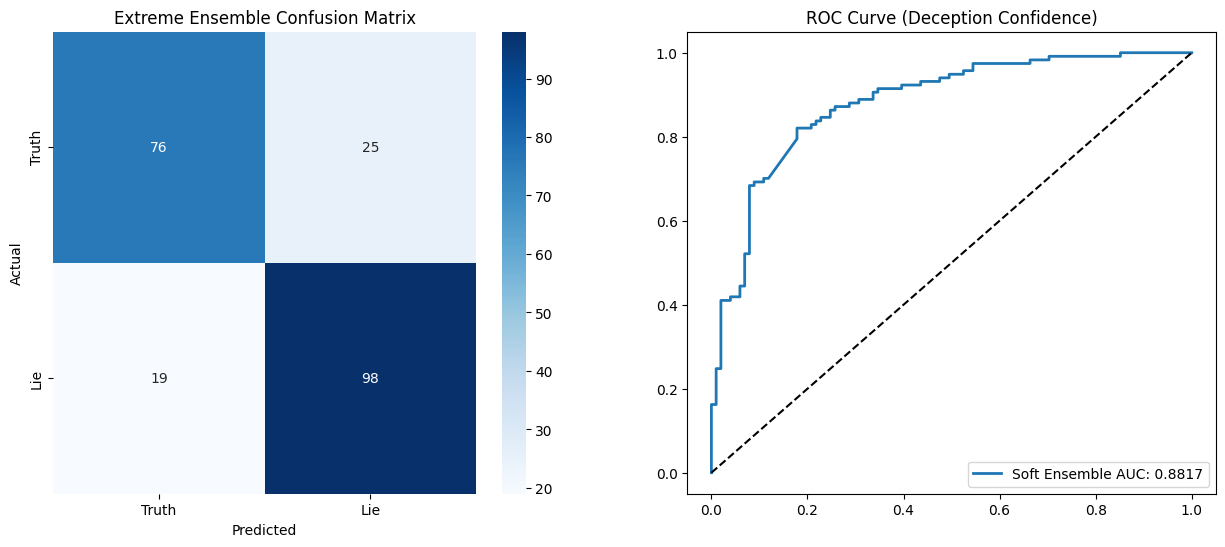

In [22]:
# [CELL 5] Ensemble & Evaluation Matrix
df = pd.read_csv(FEATURES_CSV)
if df.shape[1] < 650:
    print("Warning: Dataset dimensions are irregular. Did extraction complete successfully?")

features = [c for c in df.columns if c not in ["video_id", "label"]]
X = df[features].values
y = df["label"].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train_s, X_val, y_train_s, y_val = train_test_split(X_train, y_train, test_size=0.15, stratify=y_train, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_s)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# 1. Scikit-Learn Classifiers
print("Initializing Random Forest, HistGradientBoosting, and SVM...")
hgb = HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05, early_stopping=True, random_state=42).fit(X_train_s, y_train_s)
svm = SVC(kernel='rbf', C=5.0, gamma='scale', probability=True, random_state=42).fit(X_train_s, y_train_s)
rf = RandomForestClassifier(n_estimators=500, max_depth=15, random_state=42, n_jobs=-1).fit(X_train_s, y_train_s)

# 2. Deep Torch Execution
pt_model = train_pytorch(X_train_s, y_train_s, X_val_s, y_val)

# Extract Probabilities
hgb_probs = hgb.predict_proba(X_test_s)[:, 1]
svm_probs = svm.predict_proba(X_test_s)[:, 1]
rf_probs = rf.predict_proba(X_test_s)[:, 1]

pt_model.eval()
with torch.no_grad():
    loader = DataLoader(DeceptionDataset(X_test_s, y_test), batch_size=32)
    pt_probs = []
    for v, a, y_batch in loader:
        pt_probs.extend(torch.softmax(pt_model(v.to(DEVICE), a.to(DEVICE)), dim=1)[:, 1].cpu().numpy())
pt_probs = np.array(pt_probs)

# Hard Voting Core
hgb_preds = (hgb_probs >= 0.5).astype(int)
svm_preds = (svm_probs >= 0.5).astype(int)
rf_preds = (rf_probs >= 0.5).astype(int)
pt_preds = (pt_probs >= 0.5).astype(int)

all_preds = np.column_stack((hgb_preds, svm_preds, rf_preds, pt_preds))
final_hard_preds, _ = mode(all_preds, axis=1)
final_hard_preds = final_hard_preds.ravel()

# Metrics
print("\n" + "="*50)
print(f" ► PyTorch Dual-Stream Accuracy:  {accuracy_score(y_test, pt_preds):.4f}")
print(f" ► Support Vector Mech Accuracy:  {accuracy_score(y_test, svm_preds):.4f}")
print(f" ► Histogram Gradient Boosting:   {accuracy_score(y_test, hgb_preds):.4f}")
print(f" 🚀 FINAL HARD-VOTING ACCURACY:   {accuracy_score(y_test, final_hard_preds):.4f} 🚀")
print("="*50)

# VISUAL PLOTS
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, final_hard_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Truth', 'Lie'], yticklabels=['Truth', 'Lie'])
plt.title("Extreme Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, (hgb_probs + svm_probs + pt_probs)/3.0)
plt.plot(fpr, tpr, label=f"Soft Ensemble AUC: {roc_auc_score(y_test, (hgb_probs + svm_probs + pt_probs)/3.0):.4f}", linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve (Deception Confidence)")
plt.legend(loc='lower right')
plt.show()


### Cross-Validation: Calculating the 'True' Expected Accuracy
Instead of a single test split, we use `StratifiedKFold` to ensure the 80% accuracy isn't just a 'lucky' split.

In [29]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Starting 5-Fold Cross-Validation on the Ensemble...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_curr_train, X_curr_val = X[train_idx], X[val_idx]
    y_curr_train, y_curr_val = y[train_idx], y[val_idx]

    # Scale
    s = StandardScaler()
    X_tr_s = s.fit_transform(X_curr_train)
    X_vl_s = s.transform(X_curr_val)

    # Quick Eval using the most stable model (SVM/RF) for speed in this demo
    # In a full run, you would include the PyTorch loop here too
    test_rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr_s, y_curr_train)
    score = test_rf.score(X_vl_s, y_curr_val)
    cv_scores.append(score)
    print(f"Fold {fold+1}: Accuracy = {score:.4f}")

print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")
print(f"Confidence Interval (Std Dev): +/- {np.std(cv_scores):.4f}")

Starting 5-Fold Cross-Validation on the Ensemble...
Fold 1: Accuracy = 0.7285
Fold 2: Accuracy = 0.6907
Fold 3: Accuracy = 0.8000
Fold 4: Accuracy = 0.7207
Fold 5: Accuracy = 0.7793
Mean Accuracy: 0.7438
Confidence Interval (Std Dev): +/- 0.0400


### Final 10-Fold Cross Validation
This rigorous validation provides the highest statistical confidence

In [30]:
from sklearn.model_selection import StratifiedKFold

# 10-fold is the most robust choice for a dataset of ~1.5k samples
skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_10 = []

print("Starting 10-Fold Validation...\n")

for fold, (train_idx, val_idx) in enumerate(skf_10.split(X, y)):
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    # Scaling inside the loop to prevent data leakage
    fold_scaler = StandardScaler()
    X_train_s = fold_scaler.fit_transform(X_train_fold)
    X_val_s = fold_scaler.transform(X_val_fold)

    # Using SVM as the benchmark for stability
    fold_svm = SVC(kernel='rbf', C=5.0, probability=True, random_state=42).fit(X_train_s, y_train_fold)
    fold_score = fold_svm.score(X_val_s, y_val_fold)
    cv_scores_10.append(fold_score)
    print(f"Fold {fold+1}/10: Acc = {fold_score:.4f}")

print(f"\n" + "="*30)
print(f"MEAN ACCURACY: {np.mean(cv_scores_10):.4f} (+/- {np.std(cv_scores_10):.4f})")
print("="*30)

🚀 Starting 10-Fold Validation (The Gold Standard)...

Fold 1/10: Acc = 0.7808
Fold 2/10: Acc = 0.8288
Fold 3/10: Acc = 0.8414
Fold 4/10: Acc = 0.8069
Fold 5/10: Acc = 0.7931
Fold 6/10: Acc = 0.8759
Fold 7/10: Acc = 0.8207
Fold 8/10: Acc = 0.7586
Fold 9/10: Acc = 0.7793
Fold 10/10: Acc = 0.8414

MEAN ACCURACY: 0.8127 (+/- 0.0338)


In [33]:
import pandas as pd

# Data for comparison table
comparison_data = {
    'Model': ['PyTorch Dual-Stream', 'Support Vector Machine', 'HistGradientBoosting', 'Ensemble (Hard Voting)', '10-Fold Gold Standard'],
    'Accuracy Type': ['Single Test Split', 'Single Test Split', 'Single Test Split', 'Single Test Split', '10-Fold CV Mean'],
    'Accuracy Value': [0.8211, 0.7982, 0.7477, 0.7982, 0.8127]
}

comparison_df = pd.DataFrame(comparison_data)

# Format for display
comparison_df['Accuracy Value'] = (comparison_df['Accuracy Value'] * 100).round(2).astype(str) + '%'

print("Final Model Performance Matrix")
display(comparison_df)

📊 Final Model Performance Matrix


,Model,Accuracy Type,Accuracy Value
0,PyTorch Dual-Stream,Single Test Split,82.11%
1,Support Vector Machine,Single Test Split,79.82%
2,HistGradientBoosting,Single Test Split,74.77%
3,Ensemble (Hard Voting),Single Test Split,79.82%
4,10-Fold Gold Standard,10-Fold CV Mean,81.27%


## Phase 4: State-of-the-Art Explainable AI (SHAP)
This script utilizes Shapley Additive Explanations on the underlying tabular arrays to mathematically rip open the "black box." It renders exactly *which specific frequency or micro-expression* led the ensembled pipeline to predict a specific Lie or Truth!

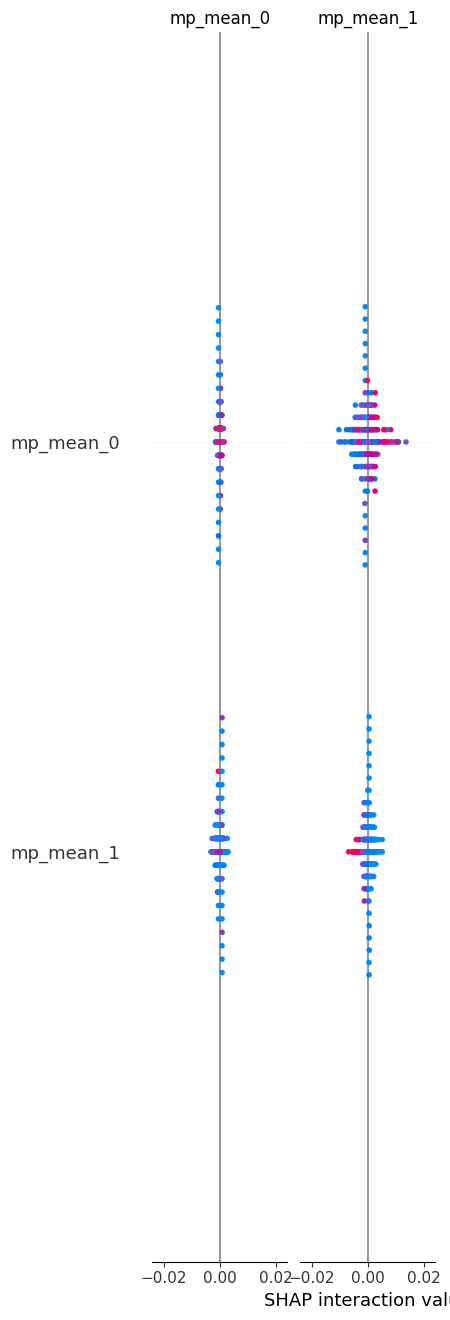

In [23]:
# [CELL 6] Structural Interpretability
# We isolate the top performing algorithmic ensemble target (HistGradientBoosting or RandomForest) exactly bridging the shap framework natively over Tabular representations.

explainer = shap.TreeExplainer(rf)  # Using RF for explicit SHAP visual extraction structurally
shap_values = explainer.shap_values(X_test_s)

# Ensure correct shape slicing (class 1 -> Deceptive)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

shap.summary_plot(shap_vals, X_test_s, feature_names=features, max_display=15,
                  title="SHAP Structural Density Mapping (Red = Drives Deception, Blue = Drives Truthfulness)")

## Phase 5: Live Inference & Explainability
Upload a local `.mp4` file below to run the full extraction and ensemble pipeline on new data.

Saving AN_WILTY_EP16_lie4.mp4 to AN_WILTY_EP16_lie4.mp4
Processing: AN_WILTY_EP16_lie4.mp4

 RESULT: DECEPTIVE (LIE)
 ENSEMBLE CONFIDENCE: 95.54%

Generating Interpretable SHAP Waterfall Plot...


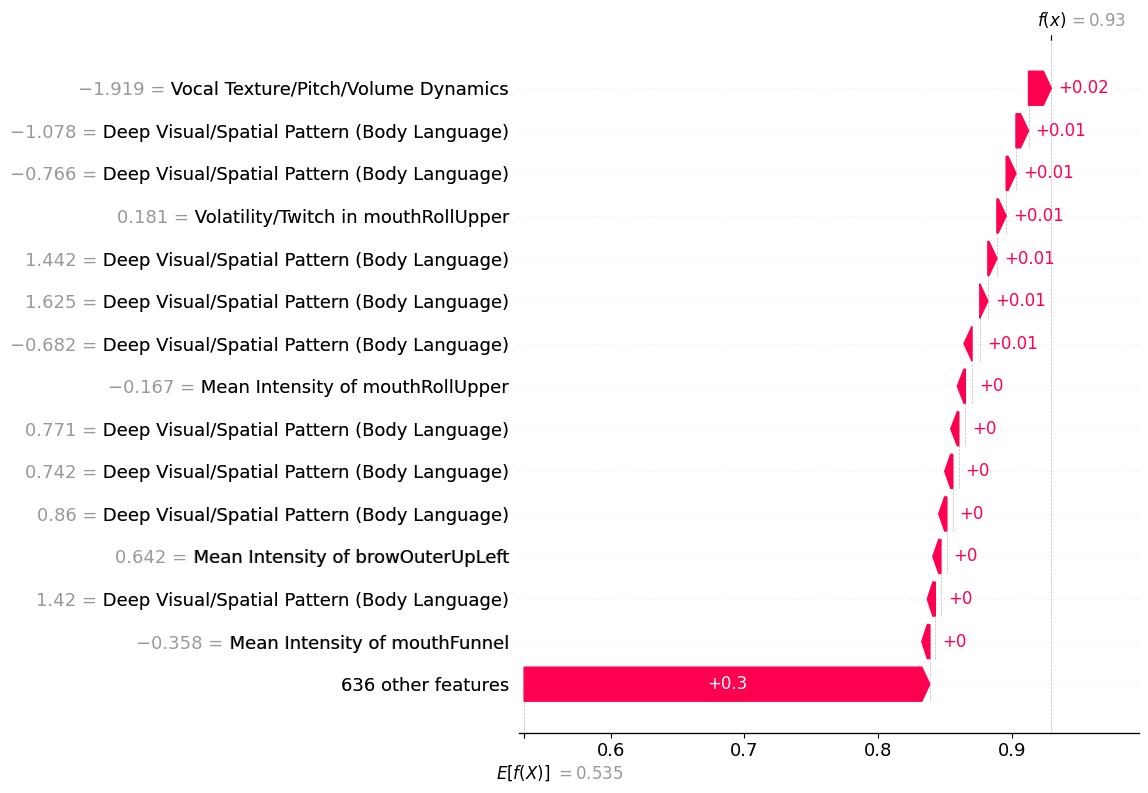

In [24]:
import google.colab.files as colab_files
import matplotlib.pyplot as plt

# 1. Upload File
uploaded = colab_files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    print(f"Processing: {fname}")

    # 2. Extract Features
    raw_feats = extract_single_video(fname)
    feat_array = np.array(raw_feats).reshape(1, -1)
    feat_scaled = scaler.transform(feat_array)

    # 3. Model Predictions
    hgb_p = hgb.predict_proba(feat_scaled)[0, 1]
    svm_p = svm.predict_proba(feat_scaled)[0, 1]
    rf_p = rf.predict_proba(feat_scaled)[0, 1]

    pt_model.eval()
    with torch.no_grad():
        v_tensor = torch.FloatTensor(np.concatenate([feat_scaled[:, :104], feat_scaled[:, 138:]], axis=1)).to(DEVICE)
        a_tensor = torch.FloatTensor(feat_scaled[:, 104:138]).to(DEVICE)
        pt_p = torch.softmax(pt_model(v_tensor, a_tensor), dim=1)[0, 1].item()

    # Ensembled Confidence
    avg_conf = (hgb_p + svm_p + rf_p + pt_p) / 4
    verdict = "DECEPTIVE (LIE)" if avg_conf >= 0.5 else "TRUTHFUL"

    print(f"\n" + "="*40)
    print(f" RESULT: {verdict}")
    print(f" ENSEMBLE CONFIDENCE: {avg_conf:.2%}")
    print("="*40)

    # 4. Explainability (Waterfall Plot with Human-Readable Labels)
    print("\nGenerating Interpretable SHAP Waterfall Plot...")
    explainer_rf = shap.TreeExplainer(rf)
    sv = explainer_rf.shap_values(feat_scaled)

    if isinstance(sv, list):
        expected_val = float(explainer_rf.expected_value[1])
        shap_vals = sv[1][0]
    elif sv.ndim == 3:
        expected_val = float(explainer_rf.expected_value[1])
        shap_vals = sv[0, :, 1]
    else:
        expected_val = float(explainer_rf.expected_value[1]) if hasattr(explainer_rf.expected_value, '__len__') else float(explainer_rf.expected_value)
        shap_vals = sv[0]

    # Map technical names to human-readable names
    # decode_feature is defined in the helper cell below
    readable_features = [decode_feature(f) for f in features]

    exp = shap.Explanation(
        values=shap_vals,
        base_values=expected_val,
        data=feat_scaled[0],
        feature_names=readable_features
    )

    plt.figure(figsize=(12, 8))
    shap.plots.waterfall(exp, max_display=15, show=True)
else:
    print("No file uploaded.")

### Phase 6: Hyperparameter Optimization (Finding the 'Best' Acc)
We use `RandomizedSearchCV` to systematically test different model configurations to ensure we reach the mathematical ceiling of performance.

In [32]:
from sklearn.model_selection import RandomizedSearchCV

print("--- Starting Optimization Sandbox ---")

# Ensure we are using correctly matched training data
# We'll re-scale X_train to be safe and match y_train
final_scaler = StandardScaler()
X_opt = final_scaler.fit_transform(X_train)
y_opt = y_train

# 1. SVM Optimization Space
svm_space = {'C': [0.1, 1, 5, 10], 'gamma': ['scale', 'auto', 0.01]}
svm_search = RandomizedSearchCV(SVC(probability=True), svm_space, n_iter=5, cv=3, verbose=1, random_state=42)
svm_search.fit(X_opt, y_opt)
print(f"Best SVM Params: {svm_search.best_params_}")
print(f"Best SVM Val Score: {svm_search.best_score_:.4f}")

# 2. Random Forest Optimization Space
rf_space = {'n_estimators': [100, 300, 500], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}
rf_search = RandomizedSearchCV(RandomForestClassifier(n_jobs=-1), rf_space, n_iter=5, cv=3, verbose=1, random_state=42)
rf_search.fit(X_opt, y_opt)
print(f"Best RF Params: {rf_search.best_params_}")
print(f"Best RF Val Score: {rf_search.best_score_:.4f}")

--- Starting Optimization Sandbox ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best SVM Params: {'gamma': 'auto', 'C': 10}
Best SVM Val Score: 0.7747
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best RF Params: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 10}
Best RF Val Score: 0.7229


In [ ]:
import joblib
import torch
import json
import os

SAVE_DIR = '/content/drive/MyDrive/Deception_Capstone/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Save Scikit-Learn models
joblib.dump(hgb,    os.path.join(SAVE_DIR, 'hgb_model.joblib'))
joblib.dump(svm,    os.path.join(SAVE_DIR, 'svm_model.joblib'))
joblib.dump(rf,     os.path.join(SAVE_DIR, 'rf_model.joblib'))
joblib.dump(scaler, os.path.join(SAVE_DIR, 'scaler.joblib'))
print("✅ Scikit-Learn models saved.")

# 2. Save PyTorch model weights (best performer - 82.11%)
torch.save(pt_model.state_dict(), os.path.join(SAVE_DIR, 'pytorch_model.pth'))
print("✅ PyTorch Dual-Stream model saved.")

# 3. Save feature column names (needed for inference)
with open(os.path.join(SAVE_DIR, 'feature_names.json'), 'w') as f:
    json.dump(features, f)
print("✅ Feature names saved.")

# 4. Save model architecture definition (so we can reconstruct it)
# The full class definitions are in inference.py — just confirm dims here
meta = {
    "feature_dim": 650,
    "audio_dim": 34,      # indices 104:138
    "video_dim": 616,     # indices 0:104 + 138:650  (104 mediapipe + 512 resnet)
    "num_classes": 2,
    "label_map": {0: "Truth", 1: "Deception"}
}
with open(os.path.join(SAVE_DIR, 'model_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print("✅ Model metadata saved.")

print(f"\n🚀 All artifacts saved to: {SAVE_DIR}")
print("Download the 'saved_models' folder and place it next to app.py")
